In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mohamedgamar","key":"d4b29d0a77952c194ad4dba3fa6f474e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

! kaggle competitions download -c titanic

  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 14.2MB/s]


In [3]:
!unzip titanic -d train_data

Archive:  titanic.zip
  inflating: train_data/gender_submission.csv  
  inflating: train_data/test.csv     
  inflating: train_data/train.csv    


In [4]:
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv('/content/train_data/train.csv')
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
data = pd.read_csv('/content/train_data/train.csv')
print(len(data.Age.unique()))
data['Cabin']=data['Cabin'].fillna('none')
data['Embarked']=data['Embarked'].fillna('none')
#data = data.drop(columns=['name' , 'Ticket' , 'Embarked'])

data["Age"]=data["Age"].fillna(data["Age"].mean())
data.isna().sum()



89


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
le = LabelEncoder()
obj_col = data.select_dtypes(include=['object']).columns
for col in obj_col:
  data[col] = le.fit_transform(data[col])
numerical_cols = data.select_dtypes(include=["int64", "float64"]).columns.drop("Survived")
st = StandardScaler()
data[numerical_cols] = st.fit_transform(data[numerical_cols])



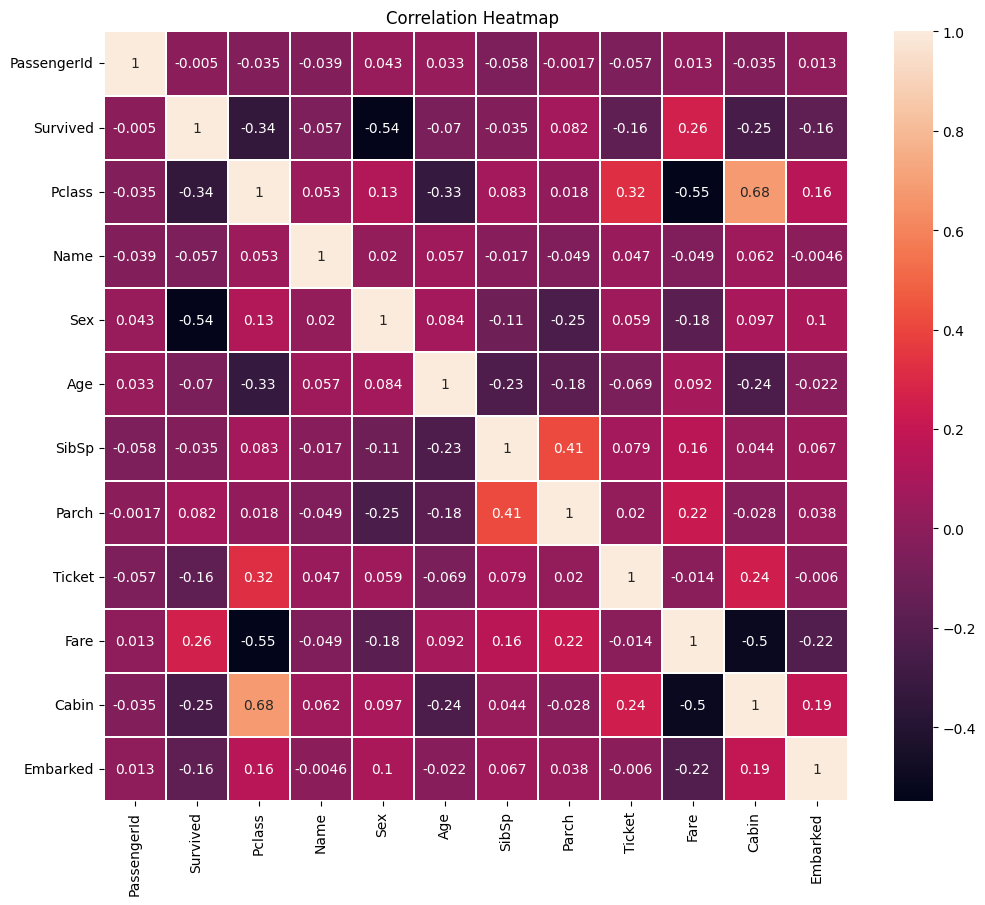

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
features_to_check = data.columns

corr_matrix = data[features_to_check].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True,  linewidths=0.1)

plt.title('Correlation Heatmap ')
plt.show()

In [9]:
data_test = pd.read_csv('/content/train_data/test.csv')
data_test['Cabin']=data_test['Cabin'].fillna('none')
data_test['Embarked']=data_test['Embarked'].fillna('none')
data_test["Age"]=data_test["Age"].fillna(data_test["Age"].mean())
data_test= data_test.fillna(0)
data_tests = data_test["PassengerId"]
obj_col = data_test.select_dtypes(include=['object']).columns
for col in obj_col:
  data_test[col] = le.fit_transform(data_test[col])
data_test.isna().sum()


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


In [10]:
numerical_cols = data_test.select_dtypes(include=["int64", "float64"]).columns
st = StandardScaler()
data_test[numerical_cols] = st.fit_transform(data_test[numerical_cols])


In [11]:
x = data.drop(columns="Survived" , axis=1)
y = data["Survived"]

In [12]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_tset = train_test_split(x,y,test_size=0.2,stratify=y)

In [13]:
%pip install kagglehub catboost xgboost tqdm -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [29]:

sklearn_models = {
    'LogisticRegression':LogisticRegression(),
  "K-Nearest Neighbors": KNeighborsClassifier(
      n_neighbors=3,  # Number of neighbors to consider
  ),
  "Support Vector Machine": SVC(
      kernel='rbf',  # 'linear', 'poly', 'rbf', 'sigmoid'
      C=0.75  # Regularization parameter
  ),
  "Decision Tree": DecisionTreeClassifier(
      max_depth=3  # Maximum depth of tree (prevents overfitting)
  ),
  "Random Forest": RandomForestClassifier(

  ),
  "XGBoost": XGBClassifier(
      verbosity=0,
      n_estimators=300,  # Number of boosting rounds
      max_depth=5,
      learning_rate=0.05 # Step size shrinkage
  ),
  "CatBoost": CatBoostClassifier(
      verbose=0,
      n_estimators=320,
      max_depth=4
  )
}

for name , model in sklearn_models.items():
  model.fit(x_train,y_train)
  print(f'{name} has Acc : {model.score(x_test, y_tset)}')

LogisticRegression has Acc : 0.7988826815642458
K-Nearest Neighbors has Acc : 0.7932960893854749
Support Vector Machine has Acc : 0.8212290502793296
Decision Tree has Acc : 0.8212290502793296
Random Forest has Acc : 0.88268156424581
XGBoost has Acc : 0.8435754189944135
CatBoost has Acc : 0.8435754189944135


In [51]:
model_LogisticRegression=LogisticRegression()
model_LogisticRegression.fit(x_train,y_train)
LogisticRegressionP=model_LogisticRegression.predict_proba(x_test)

model_KNeighborsClassifier=KNeighborsClassifier(n_neighbors=3)
model_KNeighborsClassifier.fit(x_train,y_train)
KNeighborsClassifierP=model_KNeighborsClassifier.predict_proba(x_test)

model_SVC=SVC( kernel='rbf',   C=0.75 ,probability=True  )
model_SVC.fit(x_train,y_train)
SVCP=model_SVC.predict_proba(x_test)

model_DecisionTree=DecisionTreeClassifier( max_depth=3  )
model_DecisionTree.fit(x_train,y_train)
DecisionTreeP=model_DecisionTree.predict_proba(x_test)

model_RandomForestClassifier=RandomForestClassifier()
model_RandomForestClassifier.fit(x_train,y_train)
RandomForestClassifierP=model_RandomForestClassifier.predict_proba(x_test)

model_XGB=XGBClassifier( verbosity=0, n_estimators=300, max_depth=5, learning_rate=0.05  )
model_XGB.fit(x_train,y_train)
XGBP=model_XGB.predict_proba(x_test)


model_CatBoost=CatBoostClassifier(verbose=0,n_estimators=320,max_depth=4)
model_CatBoost.fit(x_train,y_train)
CatBoostP=model_CatBoost.predict_proba(x_test)

Final = (LogisticRegressionP+KNeighborsClassifierP+SVCP+DecisionTreeP+RandomForestClassifierP+XGBP+CatBoostP)/7



In [52]:
from sklearn.metrics import accuracy_score
y_final = np.argmax(Final, axis=1)
accuracy_score(y_final,y_tset)

0.8603351955307262

In [63]:
from sklearn.ensemble import VotingClassifier
es = [('lr', model_LogisticRegression),('knn',model_KNeighborsClassifier),('svm',model_SVC),('dt',model_DecisionTree),('rf',model_RandomForestClassifier),('xgb',model_XGB),('cat',model_CatBoost)]
model = VotingClassifier(estimators=es,voting='soft',weights=[1,1,1,1,3,2,2])
model.fit(x_train,y_train)
model.score(x_test,y_tset)

0.8770949720670391

In [26]:
model.fit(x,y)
pred = model.predict(data_test)


In [27]:
output = pd.DataFrame({"PassengerId" : data_tests , 'Survived' : pred})
output.to_csv('sum.csv' , index = False)
